In [ ]:
#MIT License

#Copyright (c) 2025 Jonas Rotter

#Permission is hereby granted, free of charge, to any person obtaining a copy
#of this software and associated documentation files (the "Software"), to deal
#in the Software without restriction, including without limitation the rights
#to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
#copies of the Software, and to permit persons to whom the Software is
#furnished to do so, subject to the following conditions:

#The above copyright notice and this permission notice shall be included in all
#copies or substantial portions of the Software.

#THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
#IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
#FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
#AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
#LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
#OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
#SOFTWARE.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("data/9082ad42-b5ba-449f-ad10-1b988ac79eaa.h5ad")

In [54]:
# Confirm 'SLC16A2' is in the 'Gene' column
if 'SLC16A2' not in adata.var['Gene'].values:
    raise ValueError("Gene SLC16A2 not found in adata.var['Gene']")

# Get boolean mask for SLC16A2 gene
gene_mask = adata.var['Gene'] == 'SLC16A2'

# Extract expression data for SLC16A2 (cells × 1 gene)
expr = adata[:, gene_mask].X

# Convert sparse to dense if needed
if hasattr(expr, "toarray"):
    expr = expr.toarray()

# Flatten to 1D array
expr = expr.flatten()

# Add binary expression status to obs
adata.obs['expressing_SLC16A2'] = expr > 1  # Or > 1 for stricter threshold

# Group by both cell type and tissue to compute total and expressing cells
grouped = adata.obs.groupby(['cell_type', 'tissue']).agg(
    total_cells=('expressing_SLC16A2', 'size'),
    expressing_cells=('expressing_SLC16A2', 'sum')
)

# Calculate fraction expressing
grouped['fraction_expressing'] = (
    grouped['expressing_cells'] / grouped['total_cells']
)

# Reshape to 2D DataFrame: rows = cell types, columns = tissues
fraction_matrix = grouped['fraction_expressing'].unstack(fill_value=0)

# Optional: display or save
print(fraction_matrix)

tissue                                  cerebral cortex      pons  midbrain  \
cell_type                                                                     
fibroblast                                     0.030743  0.024802  0.029577   
ependymal cell                                 0.000000  0.032941  0.032609   
endothelial cell                               0.061655  0.074951  0.087719   
astrocyte                                      0.024006  0.012999  0.026284   
oligodendrocyte                                0.008417  0.005948  0.010488   
vascular associated smooth muscle cell         0.014599  0.011111  0.000000   
Bergmann glial cell                                 NaN  0.026846  0.000000   
pericyte                                       0.006356  0.014925  0.023438   
choroid plexus epithelial cell                 0.000000  0.000000  0.000000   
central nervous system macrophage              0.000147  0.000000  0.000070   
oligodendrocyte precursor cell                 0.031

/tmp/ipykernel_3152620/3957862061.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(['cell_type', 'tissue']).agg(


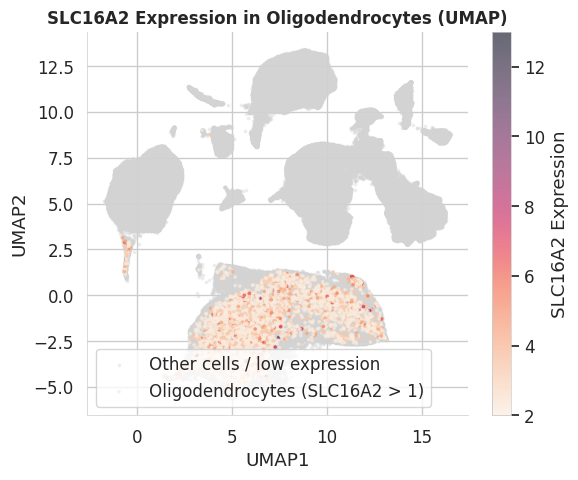

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure SLC16A2 is present
if 'SLC16A2' not in adata.var['Gene'].values:
    raise ValueError("Gene SLC16A2 not found in adata.var['Gene']")

# Boolean mask to locate the gene in adata.var
gene_mask = adata.var['Gene'] == 'SLC16A2'

# Extract expression values
expr = adata[:, gene_mask].X
if hasattr(expr, "toarray"):
    expr = expr.toarray()
expr = expr.flatten()

# Add expression to obs
adata.obs['SLC16A2_expr'] = expr

# Identify oligodendrocytes
oligo_mask = adata.obs['cell_type'].str.lower() == 'oligodendrocyte'

# Create mask for oligodendrocytes with expression > 1
oligo_expr_mask = oligo_mask & (adata.obs['SLC16A2_expr'] > 1)

# Plot UMAP
fig, ax = plt.subplots(figsize=(6, 5))

# Plot all cells in light grey
ax.scatter(
    adata.obsm['X_UMAP'][:, 0],
    adata.obsm['X_UMAP'][:, 1],
    c='lightgrey',
    s=3,
    alpha=0.3,
    label='Other cells / low expression'
)

# Overlay oligodendrocytes with expression > 1, colored by expression
oligo_coords = adata.obsm['X_UMAP'][oligo_expr_mask]
oligo_expr = expr[oligo_expr_mask]

sc2 = ax.scatter(
    oligo_coords[:, 0],
    oligo_coords[:, 1],
    c=oligo_expr,
    cmap='rocket_r',
    s=3,
    alpha=0.6,
    label='Oligodendrocytes (SLC16A2 > 1)'
)

# Colorbar for expression
cbar = plt.colorbar(sc2, ax=ax, label='SLC16A2 Expression')

ax.set_title('SLC16A2 Expression in Oligodendrocytes (UMAP)', fontsize=12)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(loc='lower left')

sns.despine()
plt.tight_layout()
plt.savefig("umap_scl16a2_oligodendrocytes_expr_gt1.png", dpi=300)
plt.savefig("umap_scl16a2_oligodendrocytes_expr_gt1.svg")
plt.show()
